In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("./data_preprocessed2.csv", header=None)
x = df.iloc[:, :-1].values  
y = df.iloc[:, -1].values   


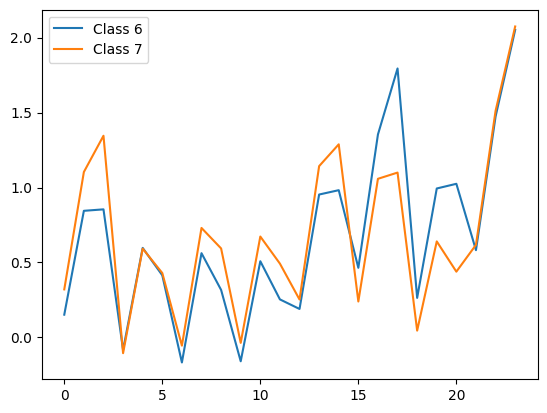

In [12]:
mean6 = x[y == 6].mean(axis=0)
mean7 = x[y == 7].mean(axis=0)

plt.plot(mean6[:200], label="Class 6")
plt.plot(mean7[:200], label="Class 7")
plt.legend()
plt.show()


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, stratify=y, random_state=42
)
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced')

Accuracy: 0.940580985915493
F1 Score: 0.9404130684703569
Classification Report:
              precision    recall  f1-score   support

           1     0.9894    0.9947    0.9920       752
           2     0.9660    0.9753    0.9706       728
           3     0.9270    0.8985    0.9125       749
           4     0.9328    0.9365    0.9347       756
           5     0.9388    0.9314    0.9351       758
           6     0.8906    0.9211    0.9056       760
           7     0.9667    0.7073    0.8169        41

    accuracy                         0.9406      4544
   macro avg     0.9445    0.9093    0.9239      4544
weighted avg     0.9408    0.9406    0.9404      4544



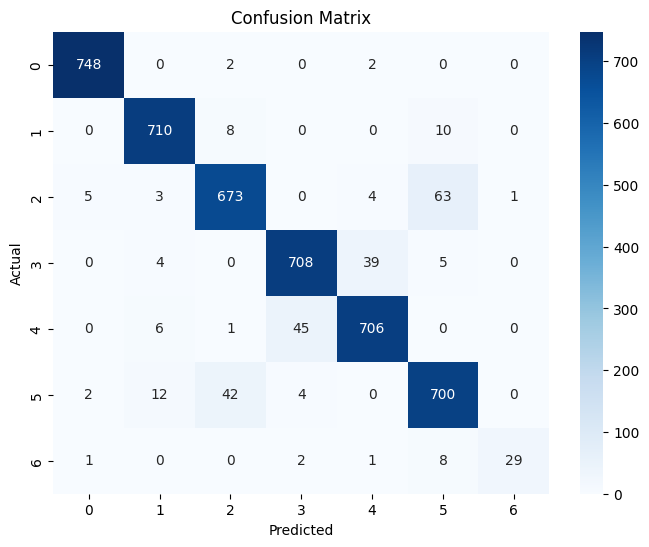

In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
pred=rf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print("F1 Score:", f1_score(y_test, pred, average='weighted'))
print("Classification Report:")
print(classification_report(y_test, pred, digits=4))
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

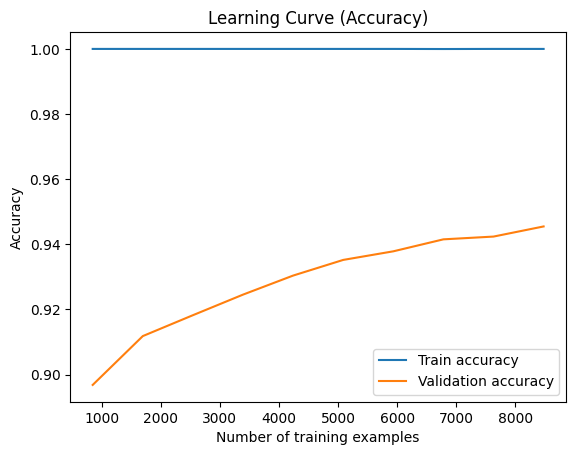

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Produce learning‐curve data
train_sizes, train_scores, test_scores = learning_curve(
    estimator=rf,
    X=X_train, y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Compute means
train_means = np.mean(train_scores, axis=1)
test_means  = np.mean(test_scores,  axis=1)

# Plot
plt.figure()
plt.plot(train_sizes, train_means, label='Train accuracy')
plt.plot(train_sizes, test_means,  label='Validation accuracy')
plt.title('Learning Curve (Accuracy)')
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.show()


SVM Accuracy: 0.8996478873239436
SVM F1 Score: 0.9008474179562334
SVM Classification Report:
              precision    recall  f1-score   support

           1     0.9740    0.9960    0.9849       752
           2     0.9378    0.9327    0.9353       728
           3     0.8697    0.8732    0.8714       749
           4     0.8924    0.8995    0.8959       756
           5     0.9091    0.8707    0.8895       758
           6     0.8676    0.8276    0.8471       760
           7     0.4302    0.9024    0.5827        41

    accuracy                         0.8996      4544
   macro avg     0.8401    0.9003    0.8581      4544
weighted avg     0.9039    0.8996    0.9008      4544



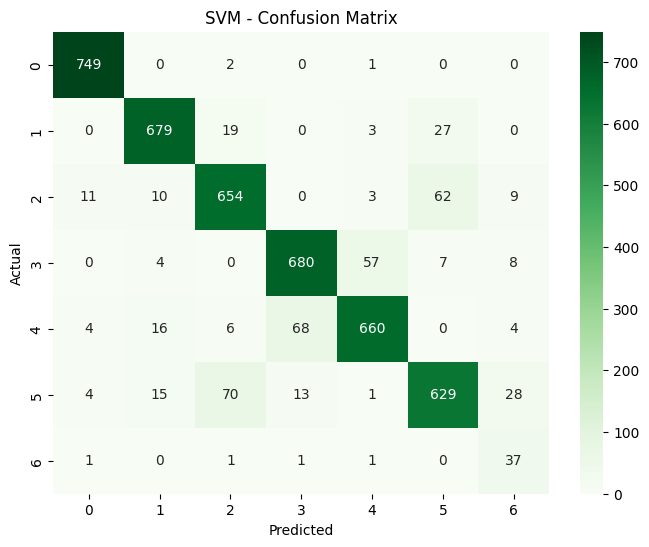

In [15]:
from sklearn.svm import SVC
svm = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
svm.fit(X_train, y_train)
pred_svm = svm.predict(X_test)
print("SVM Accuracy:", accuracy_score(y_test, pred_svm))
print("SVM F1 Score:", f1_score(y_test, pred_svm, average='weighted'))
print("SVM Classification Report:")
print(classification_report(y_test, pred_svm, digits=4))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, pred_svm), annot=True, fmt='d', cmap='Greens')
plt.title("SVM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

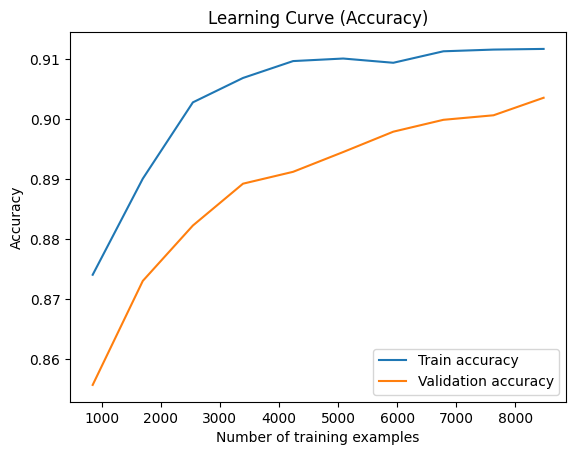

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Produce learning‐curve data
train_sizes, train_scores, test_scores = learning_curve(
    estimator=svm,
    X=X_train, y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Compute means
train_means = np.mean(train_scores, axis=1)
test_means  = np.mean(test_scores,  axis=1)

# Plot
plt.figure()
plt.plot(train_sizes, train_means, label='Train accuracy')
plt.plot(train_sizes, test_means,  label='Validation accuracy')
plt.title('Learning Curve (Accuracy)')
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.show()


Decision Tree Accuracy: 0.8851232394366197
Decision Tree F1 Score: 0.885157217205506
Decision Tree Classification Report:
              precision    recall  f1-score   support

           1     0.9880    0.9840    0.9860       752
           2     0.9116    0.9203    0.9159       728
           3     0.8386    0.8465    0.8425       749
           4     0.8760    0.8598    0.8678       756
           5     0.8705    0.8694    0.8700       758
           6     0.8377    0.8421    0.8399       760
           7     0.7073    0.7073    0.7073        41

    accuracy                         0.8851      4544
   macro avg     0.8614    0.8613    0.8614      4544
weighted avg     0.8852    0.8851    0.8852      4544



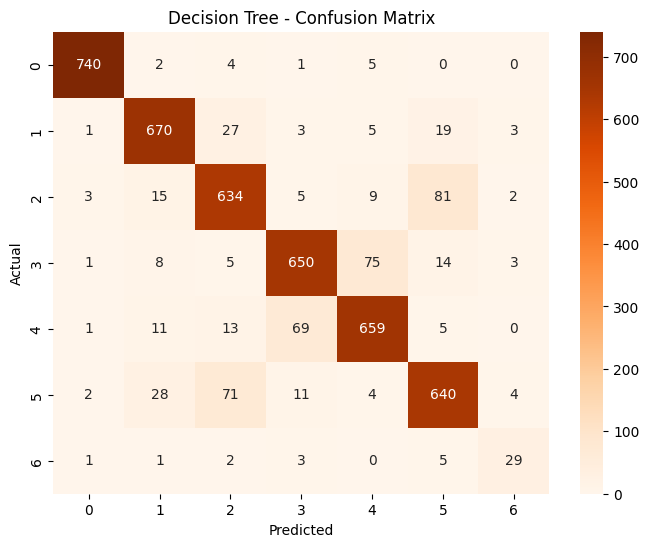

In [16]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, pred_dt))
print("Decision Tree F1 Score:", f1_score(y_test, pred_dt, average='weighted'))
print("Decision Tree Classification Report:")
print(classification_report(y_test, pred_dt, digits=4))
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, pred_dt), annot=True, fmt='d', cmap='Oranges')
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



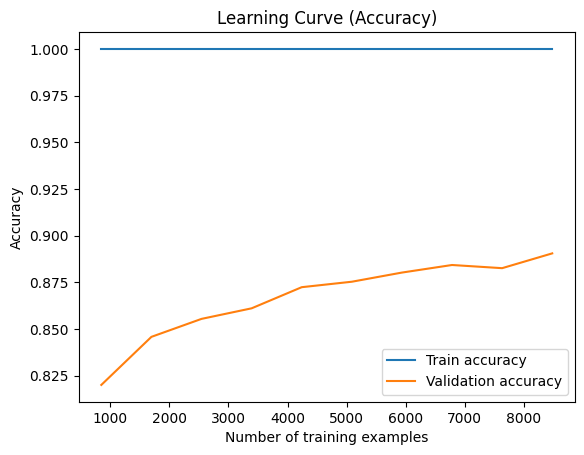

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

# Produce learning‐curve data
train_sizes, train_scores, test_scores = learning_curve(
    estimator=dt,
    X=X_train, y=y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

# Compute means
train_means = np.mean(train_scores, axis=1)
test_means  = np.mean(test_scores,  axis=1)

# Plot
plt.figure()
plt.plot(train_sizes, train_means, label='Train accuracy')
plt.plot(train_sizes, test_means,  label='Validation accuracy')
plt.title('Learning Curve (Accuracy)')
plt.xlabel('Number of training examples')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.show()


In [17]:
import numpy as np
import math
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
P = len(y)
k = int(math.floor(math.log2(P)))
if k % 2 == 0:
    k += 1
pipeline = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=k)
)
pipeline.fit(x, y)
train_acc = pipeline.score(x, y)
print(f"Training accuracy: {train_acc:.4f} using k={k}")


Training accuracy: 0.9387 using k=13


In [18]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(rf, x, y, cv=5, scoring='f1_weighted')
print("Cross-validated F1-score:", scores.mean())
from sklearn.model_selection import cross_val_score
scores = cross_val_score(svm, x, y, cv=5, scoring='f1_weighted')
print("Cross-validated F1-score:", scores.mean())
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(
    pipeline,
    x,
    y,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=-1
)

print(f"Cross-validated F1-weighted (5 folds): {np.mean(scores):.4f} (std: {np.std(scores):.4f}), k={k}")


Cross-validated F1-score: 0.8694232654784886
Cross-validated F1-score: 0.8596691547826818
Cross-validated F1-weighted (5 folds): 0.9231 (std: 0.0030), k=13


In [19]:
import joblib

joblib.dump(dt, "decision_tree_no0.hs")
joblib.dump(rf, "random_forest_no0.hs")
joblib.dump(svm, "svm_no0.hs")


['svm_no0.hs']